# PX4 Phase 1 Rate Dynamics PINN Training v10 Relaxed Nominal Test

v10 backs away from the strong v9 hybrid physics constraint.

Main changes:

- Use a nominal scenario-stratified test split instead of treating noisy/stress sequences as the main test set.
- Keep `N11_mixed_sequence` as `stress_test_df`, not as the primary test metric.
- Return to a v7-style direct `dx` model with an auxiliary acceleration head.
- Keep physics-informed losses weak and diagnostic, not dominant.

Runtime contract remains:

```text
x_t, u_t, prev_u_t, du_t, dt_s -> dx_t
```


In [1]:
# Colab setup
from pathlib import Path
import json
import math
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
device: cuda
torch: 2.10.0+cu128


In [2]:
# Dataset path
# Prefer v4 filtered dataset. Set manually if needed.
DATASET_DIR = ''  # e.g. '/content/drive/MyDrive/px4_datasets/processed/px4_phase1_rate_dynamics_dataset_v4_filtered_imu_aux_20260508_180000'

def find_latest_dataset_dir():
    import glob
    patterns = [
        '/content/drive/MyDrive/**/px4_phase1_rate_dynamics_dataset_v4_filtered_imu_aux_*',
        '/content/**/px4_phase1_rate_dynamics_dataset_v4_filtered_imu_aux_*',
        './px4_phase1_rate_dynamics_dataset_v4_filtered_imu_aux_*',
        '/content/drive/MyDrive/**/px4_phase1_rate_dynamics_dataset_v3_imu_aux_*',
    ]
    matches=[]
    for pat in patterns:
        matches.extend(glob.glob(pat, recursive=True))
    matches=sorted(set(matches))
    matches=[Path(m) for m in matches if (Path(m)/'train.csv').exists()]
    if not matches:
        raise FileNotFoundError('No v4/v3 processed dataset found. Set DATASET_DIR manually.')
    return matches[-1]

DATASET_PATH = Path(DATASET_DIR) if DATASET_DIR else find_latest_dataset_dir()
print('DATASET_PATH:', DATASET_PATH)
print('files:', sorted([p.name for p in DATASET_PATH.iterdir()])[:20])


DATASET_PATH: /content/drive/MyDrive/px4_datasets/processed/px4_phase1_rate_dynamics_dataset_v4_filtered_imu_aux_20260508_175455
files: ['all_samples.csv', 'dataset_summary.csv', 'filter_report.csv', 'metadata.json', 'source_summary.csv', 'test.csv', 'train.csv', 'val.csv']


In [3]:
# Load data and create relaxed nominal/stress split
base_train = pd.read_csv(DATASET_PATH / 'train.csv')
base_val = pd.read_csv(DATASET_PATH / 'val.csv')
base_test = pd.read_csv(DATASET_PATH / 'test.csv')
all_df = pd.read_csv(DATASET_PATH / 'all_samples.csv') if (DATASET_PATH / 'all_samples.csv').exists() else pd.concat([base_train, base_val, base_test], ignore_index=True)

metadata = {}
if (DATASET_PATH / 'metadata.json').exists():
    metadata = json.loads((DATASET_PATH / 'metadata.json').read_text())

state_cols = metadata.get('state_cols') or [c.removeprefix('dx_') for c in all_df.columns if c.startswith('dx_')]
action_cols = metadata.get('action_cols') or [c.removeprefix('u_') for c in all_df.columns if c.startswith('u_')]
feature_cols = [f'x_{c}' for c in state_cols] + [f'u_{c}' for c in action_cols] + [f'prev_u_{c}' for c in action_cols] + [f'du_{c}' for c in action_cols] + ['dt_s']
target_cols = [f'dx_{c}' for c in state_cols]
next_cols = [f'x_next_{c}' for c in state_cols]
aux_cols = [
    'aux_derived_accel_north_m_s2',
    'aux_derived_accel_east_m_s2',
    'aux_derived_accel_down_m_s2',
    'aux_derived_roll_accel_rad_s2',
    'aux_derived_pitch_accel_rad_s2',
    'aux_derived_yaw_accel_rad_s2',
]
missing = [c for c in feature_cols + target_cols + next_cols + aux_cols if c not in all_df.columns]
if missing:
    raise ValueError(f'Missing columns: {missing}')

needed = feature_cols + target_cols + next_cols + aux_cols
all_df = all_df[np.isfinite(all_df[needed].to_numpy(np.float32)).all(axis=1)].copy()

STRESS_SCENARIOS = ['N11_mixed_sequence']
DROP_FROM_NOMINAL = STRESS_SCENARIOS
VAL_FRACTION = 0.14
TEST_FRACTION = 0.14
MIN_GROUP_FOR_SPLIT = 30

stress_test_df = all_df[all_df['scenario'].isin(STRESS_SCENARIOS)].copy() if 'scenario' in all_df.columns else all_df.iloc[0:0].copy()
nominal_df = all_df[~all_df['scenario'].isin(DROP_FROM_NOMINAL)].copy() if 'scenario' in all_df.columns else all_df.copy()

rng = np.random.default_rng(SEED)
train_idx=[]; val_idx=[]; test_idx=[]
group_cols = [c for c in ['source_run', 'scenario'] if c in nominal_df.columns]
if group_cols:
    for _, group in nominal_df.groupby(group_cols, sort=False):
        idx = group.index.to_numpy().copy()
        rng.shuffle(idx)
        if len(idx) < MIN_GROUP_FOR_SPLIT:
            train_idx.extend(idx.tolist())
            continue
        n_test = max(1, int(round(len(idx) * TEST_FRACTION)))
        n_val = max(1, int(round(len(idx) * VAL_FRACTION)))
        test_idx.extend(idx[:n_test].tolist())
        val_idx.extend(idx[n_test:n_test+n_val].tolist())
        train_idx.extend(idx[n_test+n_val:].tolist())
else:
    idx = nominal_df.index.to_numpy().copy(); rng.shuffle(idx)
    n_test=int(round(len(idx)*TEST_FRACTION)); n_val=int(round(len(idx)*VAL_FRACTION))
    test_idx=idx[:n_test].tolist(); val_idx=idx[n_test:n_test+n_val].tolist(); train_idx=idx[n_test+n_val:].tolist()

train_df = nominal_df.loc[sorted(train_idx)].copy()
val_df = nominal_df.loc[sorted(val_idx)].copy()
test_df = nominal_df.loc[sorted(test_idx)].copy()

print('train/val/test/stress rows:', len(train_df), len(val_df), len(test_df), len(stress_test_df))
print('state_cols:', state_cols)
print('action_cols:', action_cols)
print('aux_cols:', aux_cols)
print('n_features:', len(feature_cols), 'n_targets:', len(target_cols), 'n_aux:', len(aux_cols))
if 'scenario' in all_df.columns:
    split_view = pd.concat([
        train_df.assign(split_view='train'),
        val_df.assign(split_view='val'),
        test_df.assign(split_view='test'),
        stress_test_df.assign(split_view='stress'),
    ])
    display(split_view.groupby(['split_view','scenario']).size().to_frame('rows').reset_index())


train/val/test/stress rows: 11368 2217 2217 1445
state_cols: ['relative_altitude_m', 'vel_north_m_s', 'vel_east_m_s', 'vel_down_m_s', 'roll_deg', 'pitch_deg', 'yaw_deg', 'roll_rate_rad_s', 'pitch_rate_rad_s', 'yaw_rate_rad_s']
action_cols: ['ref_roll_rate_rad_s', 'ref_pitch_rate_rad_s', 'ref_yaw_rate_rad_s', 'ref_thrust']
aux_cols: ['aux_derived_accel_north_m_s2', 'aux_derived_accel_east_m_s2', 'aux_derived_accel_down_m_s2', 'aux_derived_roll_accel_rad_s2', 'aux_derived_pitch_accel_rad_s2', 'aux_derived_yaw_accel_rad_s2']
n_features: 23 n_targets: 10 n_aux: 6


,split_view,scenario,rows
0,stress,N11_mixed_sequence,1445
1,test,N00_hover_hold_0p5192,168
2,test,N01_pitch_rate_doublet_5dps,196
3,test,N02_pitch_rate_doublet_10dps,191
4,test,N03_roll_rate_doublet_5dps,185
5,test,N04_roll_rate_doublet_10dps,196
6,test,N05_yaw_rate_doublet_10dps,196
7,test,N06_yaw_rate_doublet_20dps,293
8,test,N07_thrust_step_pm010,196
9,test,N08_thrust_step_pm020,196


In [4]:
# Scalers and dataloaders
class StandardScaler:
    def __init__(self, mean, std):
        self.mean=np.asarray(mean,dtype=np.float32)
        self.std=np.asarray(std,dtype=np.float32)
        self.std=np.where(self.std<1e-8,1.0,self.std)
    @classmethod
    def fit(cls, arr): return cls(np.nanmean(arr,axis=0), np.nanstd(arr,axis=0))
    def transform(self, arr): return (np.asarray(arr,dtype=np.float32)-self.mean)/self.std
    def inverse_transform(self, arr): return np.asarray(arr,dtype=np.float32)*self.std+self.mean
    def to_dict(self, columns): return {'columns':list(columns),'mean':self.mean.tolist(),'std':self.std.tolist()}

X_train_raw=train_df[feature_cols].to_numpy(np.float32); Y_train_raw=train_df[target_cols].to_numpy(np.float32); A_train_raw=train_df[aux_cols].to_numpy(np.float32)
X_val_raw=val_df[feature_cols].to_numpy(np.float32); Y_val_raw=val_df[target_cols].to_numpy(np.float32); A_val_raw=val_df[aux_cols].to_numpy(np.float32)
X_test_raw=test_df[feature_cols].to_numpy(np.float32); Y_test_raw=test_df[target_cols].to_numpy(np.float32); A_test_raw=test_df[aux_cols].to_numpy(np.float32)

x_scaler=StandardScaler.fit(X_train_raw)
y_scaler=StandardScaler.fit(Y_train_raw)
a_scaler=StandardScaler.fit(A_train_raw)

X_train=x_scaler.transform(X_train_raw); Y_train=y_scaler.transform(Y_train_raw); A_train=a_scaler.transform(A_train_raw)
X_val=x_scaler.transform(X_val_raw); Y_val=y_scaler.transform(Y_val_raw); A_val=a_scaler.transform(A_val_raw)
X_test=x_scaler.transform(X_test_raw); Y_test=y_scaler.transform(Y_test_raw); A_test=a_scaler.transform(A_test_raw)

BATCH_SIZE=1024
train_loader=DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(Y_train), torch.tensor(A_train)), batch_size=BATCH_SIZE, shuffle=True)
val_loader=DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(Y_val), torch.tensor(A_val)), batch_size=BATCH_SIZE, shuffle=False)

x_mean_t=torch.tensor(x_scaler.mean,dtype=torch.float32,device=device); x_std_t=torch.tensor(x_scaler.std,dtype=torch.float32,device=device)
y_mean_t=torch.tensor(y_scaler.mean,dtype=torch.float32,device=device); y_std_t=torch.tensor(y_scaler.std,dtype=torch.float32,device=device)
a_mean_t=torch.tensor(a_scaler.mean,dtype=torch.float32,device=device); a_std_t=torch.tensor(a_scaler.std,dtype=torch.float32,device=device)
feature_index={c:i for i,c in enumerate(feature_cols)}; target_index={c:i for i,c in enumerate(target_cols)}; aux_index={c:i for i,c in enumerate(aux_cols)}
print('batches:', len(train_loader), len(val_loader))


batches: 12 3


In [5]:
# Model: relaxed direct dx with auxiliary acceleration head
class RelaxedDxAuxMLP(nn.Module):
    def __init__(self, n_in, n_dx, n_aux, hidden=512, depth=5, dropout=0.02):
        super().__init__()
        layers=[]; last=n_in
        for _ in range(depth):
            layers += [nn.Linear(last,hidden), nn.SiLU(), nn.LayerNorm(hidden)]
            if dropout>0: layers.append(nn.Dropout(dropout))
            last=hidden
        self.trunk=nn.Sequential(*layers)
        self.dx_head=nn.Linear(last,n_dx)
        self.aux_head=nn.Linear(last,n_aux)
    def forward(self,x):
        z=self.trunk(x)
        return self.dx_head(z), self.aux_head(z)

MODEL_CONFIG=dict(hidden=512, depth=5, dropout=0.02)
model=RelaxedDxAuxMLP(len(feature_cols), len(target_cols), len(aux_cols), **MODEL_CONFIG).to(device)
print(model)
print('parameters:', sum(p.numel() for p in model.parameters()))


RelaxedDxAuxMLP(
  (trunk): Sequential(
    (0): Linear(in_features=23, out_features=512, bias=True)
    (1): SiLU()
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=0.02, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): SiLU()
    (6): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (7): Dropout(p=0.02, inplace=False)
    (8): Linear(in_features=512, out_features=512, bias=True)
    (9): SiLU()
    (10): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (11): Dropout(p=0.02, inplace=False)
    (12): Linear(in_features=512, out_features=512, bias=True)
    (13): SiLU()
    (14): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (15): Dropout(p=0.02, inplace=False)
    (16): Linear(in_features=512, out_features=512, bias=True)
    (17): SiLU()
    (18): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (19): Dropout(p=0.02, inplace=False)
  )
  (dx_head): Linear(in_features=512, out_f

In [6]:
# Weak physics-informed losses
EPOCHS=900
LR=1e-3
WEIGHT_DECAY=2e-5
PATIENCE=130
GRAD_CLIP=2.0

DATA_WEIGHT=1.0
AUX_WEIGHT=0.08
ALT_KIN_WEIGHT=0.035
EULER_KIN_WEIGHT=0.030
AUX_CONSISTENCY_WEIGHT=0.025
ALT_RESID_SCALE_M=0.08
EULER_RESID_SCALE_RAD=np.deg2rad(1.0)

TARGET_DATA_WEIGHTS={
    'dx_relative_altitude_m':1.25,
    'dx_vel_down_m_s':1.15,
    'dx_yaw_deg':1.10,
    'dx_yaw_rate_rad_s':1.08,
}
AUX_DATA_WEIGHTS={
    'aux_derived_accel_down_m_s2':1.10,
    'aux_derived_yaw_accel_rad_s2':1.10,
}

target_weight_vec=torch.ones(len(target_cols),dtype=torch.float32,device=device)
for name,w in TARGET_DATA_WEIGHTS.items():
    if name in target_index: target_weight_vec[target_index[name]]=float(w)
aux_weight_vec=torch.ones(len(aux_cols),dtype=torch.float32,device=device)
for name,w in AUX_DATA_WEIGHTS.items():
    if name in aux_index: aux_weight_vec[aux_index[name]]=float(w)

optimizer=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=WEIGHT_DECAY)
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=EPOCHS,eta_min=1e-5)

def smooth_l1_weighted(pred,target,weight_vec,beta=0.5):
    err=pred-target; ae=torch.abs(err)
    loss=torch.where(ae<beta,0.5*err**2/beta,ae-0.5*beta)
    return torch.mean(loss*weight_vec[None,:])

def wrap_rad(a): return torch.atan2(torch.sin(a), torch.cos(a))
def raw_feature(xb,name):
    i=feature_index[name]; return xb[:,i]*x_std_t[i]+x_mean_t[i]
def raw_pred_dx(pred_scaled,name):
    i=target_index[name]; return pred_scaled[:,i]*y_std_t[i]+y_mean_t[i]

def physics_loss(xb,pred_scaled):
    dt=raw_feature(xb,'dt_s').clamp_min(1e-4)
    vd=raw_feature(xb,'x_vel_down_m_s')
    dvd=raw_pred_dx(pred_scaled,'dx_vel_down_m_s')
    expected_dh=-0.5*(vd+vd+dvd)*dt
    pred_dh=raw_pred_dx(pred_scaled,'dx_relative_altitude_m')
    alt_loss=torch.mean(((pred_dh-expected_dh)/ALT_RESID_SCALE_M)**2)

    phi=torch.deg2rad(raw_feature(xb,'x_roll_deg'))
    theta=torch.deg2rad(raw_feature(xb,'x_pitch_deg')).clamp(-1.2,1.2)
    p=raw_feature(xb,'x_roll_rate_rad_s'); q=raw_feature(xb,'x_pitch_rate_rad_s'); r=raw_feature(xb,'x_yaw_rate_rad_s')
    tan_theta=torch.tan(theta); cos_theta=torch.cos(theta).clamp_min(0.2); sin_phi=torch.sin(phi); cos_phi=torch.cos(phi)
    phi_dot=p+tan_theta*(q*sin_phi+r*cos_phi)
    theta_dot=q*cos_phi-r*sin_phi
    psi_dot=(q*sin_phi+r*cos_phi)/cos_theta
    dphi=torch.deg2rad(raw_pred_dx(pred_scaled,'dx_roll_deg'))
    dtheta=torch.deg2rad(raw_pred_dx(pred_scaled,'dx_pitch_deg'))
    dpsi=torch.deg2rad(raw_pred_dx(pred_scaled,'dx_yaw_deg'))
    e=torch.stack([(dphi-phi_dot*dt)/EULER_RESID_SCALE_RAD,(dtheta-theta_dot*dt)/EULER_RESID_SCALE_RAD,wrap_rad(dpsi-psi_dot*dt)/EULER_RESID_SCALE_RAD],dim=1)
    return alt_loss, torch.mean(e**2)

def aux_consistency_loss(xb,pred_scaled,aux_scaled_true):
    dt=raw_feature(xb,'dt_s').clamp_min(1e-4)
    losses=[]
    pairs=[
        ('dx_vel_north_m_s','aux_derived_accel_north_m_s2'),
        ('dx_vel_east_m_s','aux_derived_accel_east_m_s2'),
        ('dx_vel_down_m_s','aux_derived_accel_down_m_s2'),
        ('dx_roll_rate_rad_s','aux_derived_roll_accel_rad_s2'),
        ('dx_pitch_rate_rad_s','aux_derived_pitch_accel_rad_s2'),
        ('dx_yaw_rate_rad_s','aux_derived_yaw_accel_rad_s2'),
    ]
    for dx_name,aux_name in pairs:
        if dx_name not in target_index or aux_name not in aux_index: continue
        raw_est=raw_pred_dx(pred_scaled,dx_name)/dt
        j=aux_index[aux_name]
        est_scaled=(raw_est-a_mean_t[j])/a_std_t[j]
        losses.append(torch.mean((est_scaled-aux_scaled_true[:,j])**2))
    return torch.stack(losses).mean() if losses else torch.tensor(0.0,device=device)


epoch 0001 train=0.4617 val=0.1805 data=0.1491 aux=0.1920 alt=0.0036 euler=0.0019 aux_cons=0.6334 best=0.1805@1
epoch 0025 train=0.1117 val=0.1090 data=0.0883 aux=0.1196 alt=0.0020 euler=0.0003 aux_cons=0.4450 best=0.1090@25
epoch 0050 train=0.1059 val=0.1068 data=0.0861 aux=0.1175 alt=0.0021 euler=0.0002 aux_cons=0.4473 best=0.1059@47
epoch 0075 train=0.1042 val=0.1036 data=0.0837 aux=0.1160 alt=0.0027 euler=0.0003 aux_cons=0.4196 best=0.1036@75
epoch 0100 train=0.1000 val=0.1030 data=0.0828 aux=0.1143 alt=0.0028 euler=0.0003 aux_cons=0.4408 best=0.1021@98
epoch 0125 train=0.0992 val=0.1026 data=0.0828 aux=0.1126 alt=0.0023 euler=0.0002 aux_cons=0.4263 best=0.1021@98
epoch 0150 train=0.0978 val=0.1022 data=0.0824 aux=0.1104 alt=0.0024 euler=0.0003 aux_cons=0.4373 best=0.1020@140
epoch 0175 train=0.0964 val=0.1026 data=0.0828 aux=0.1082 alt=0.0026 euler=0.0003 aux_cons=0.4428 best=0.1014@160
epoch 0200 train=0.0962 val=0.1026 data=0.0827 aux=0.1091 alt=0.0026 euler=0.0003 aux_cons=0.44

,epoch,train_loss,train_data,train_aux,train_alt,train_euler,train_aux_cons,val_loss,val_data,val_aux,val_alt,val_euler,val_aux_cons,lr
285,286,0.092238,0.073259,0.106633,0.002685,0.000359,0.413728,0.103533,0.083827,0.106430,0.002567,0.000315,0.443693,0.000773
286,287,0.091993,0.072891,0.106369,0.002741,0.000363,0.419438,0.103734,0.083509,0.108194,0.002536,0.000289,0.458910,0.000772
287,288,0.092375,0.073190,0.106337,0.002638,0.000366,0.423017,0.104503,0.084322,0.107781,0.002648,0.000303,0.458272,0.000770
288,289,0.092370,0.073256,0.106868,0.002771,0.000351,0.418272,0.104618,0.084528,0.107971,0.002761,0.000296,0.453883,0.000769
289,290,0.092409,0.073308,0.107328,0.002765,0.000352,0.416304,0.103762,0.083627,0.107992,0.002576,0.000328,0.455823,0.000767


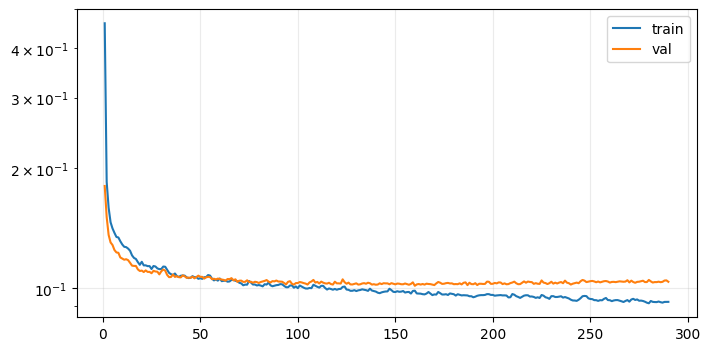

In [7]:
# Training
def run_epoch(loader,train_mode):
    model.train(train_mode)
    totals={'loss':0.0,'data':0.0,'aux':0.0,'alt':0.0,'euler':0.0,'aux_cons':0.0}; n=0
    for xb,yb,ab in loader:
        xb=xb.to(device); yb=yb.to(device); ab=ab.to(device)
        if train_mode: optimizer.zero_grad(set_to_none=True)
        pred_dx,pred_aux=model(xb)
        data_loss=smooth_l1_weighted(pred_dx,yb,target_weight_vec)
        aux_loss=smooth_l1_weighted(pred_aux,ab,aux_weight_vec)
        alt_loss,euler_loss=physics_loss(xb,pred_dx)
        aux_cons=aux_consistency_loss(xb,pred_dx,ab)
        loss=DATA_WEIGHT*data_loss + AUX_WEIGHT*aux_loss + ALT_KIN_WEIGHT*alt_loss + EULER_KIN_WEIGHT*euler_loss + AUX_CONSISTENCY_WEIGHT*aux_cons
        if train_mode:
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),GRAD_CLIP); optimizer.step()
        bs=len(xb); n+=bs
        totals['loss']+=float(loss.detach().cpu())*bs; totals['data']+=float(data_loss.detach().cpu())*bs; totals['aux']+=float(aux_loss.detach().cpu())*bs; totals['alt']+=float(alt_loss.detach().cpu())*bs; totals['euler']+=float(euler_loss.detach().cpu())*bs; totals['aux_cons']+=float(aux_cons.detach().cpu())*bs
    return {k:v/max(1,n) for k,v in totals.items()}

best_val=float('inf'); best_state=None; best_epoch=0; wait=0; history=[]; t0=time.time()
for epoch in range(1,EPOCHS+1):
    tr=run_epoch(train_loader,True); va=run_epoch(val_loader,False); scheduler.step()
    row={'epoch':epoch,**{f'train_{k}':v for k,v in tr.items()},**{f'val_{k}':v for k,v in va.items()},'lr':scheduler.get_last_lr()[0]}; history.append(row)
    if va['loss']<best_val:
        best_val=va['loss']; best_epoch=epoch; wait=0; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    else:
        wait+=1
    if epoch==1 or epoch%25==0:
        print(f"epoch {epoch:04d} train={tr['loss']:.4f} val={va['loss']:.4f} data={va['data']:.4f} aux={va['aux']:.4f} alt={va['alt']:.4f} euler={va['euler']:.4f} aux_cons={va['aux_cons']:.4f} best={best_val:.4f}@{best_epoch}")
    if wait>=PATIENCE:
        print('early stop at',epoch,'best_epoch=',best_epoch); break
if best_state is not None: model.load_state_dict(best_state)
hist_df=pd.DataFrame(history)
print('elapsed min:',round((time.time()-t0)/60,2),'best_epoch:',best_epoch,'best_val:',best_val)
display(hist_df.tail())
fig,ax=plt.subplots(figsize=(8,4)); ax.plot(hist_df['epoch'],hist_df['train_loss'],label='train'); ax.plot(hist_df['epoch'],hist_df['val_loss'],label='val'); ax.set_yscale('log'); ax.grid(True,alpha=.25); ax.legend(); plt.show()


In [8]:
# One-step metrics
@torch.no_grad()
def predict_all(df):
    x=x_scaler.transform(df[feature_cols].to_numpy(np.float32))
    dx_parts=[]; aux_parts=[]; model.eval()
    for i in range(0,len(x),4096):
        xb=torch.tensor(x[i:i+4096],dtype=torch.float32,device=device)
        dx_scaled,aux_scaled=model(xb)
        dx_parts.append(dx_scaled.detach().cpu().numpy()); aux_parts.append(aux_scaled.detach().cpu().numpy())
    return y_scaler.inverse_transform(np.concatenate(dx_parts)), a_scaler.inverse_transform(np.concatenate(aux_parts))

def metric_table(split,cols,pred,true):
    rows=[]
    for j,c in enumerate(cols):
        err=pred[:,j]-true[:,j]
        if c=='dx_yaw_deg': err=(err+180)%360-180
        rows.append({'split':split,'target':c,'rmse':float(np.sqrt(np.mean(err**2))),'mae':float(np.mean(np.abs(err))),'std_true':float(np.std(true[:,j]))})
    return pd.DataFrame(rows)

parts=[]; aux_parts=[]
for split,df in [('train',train_df),('val',val_df),('test',test_df),('stress',stress_test_df)]:
    if len(df)==0: continue
    pdx,paux=predict_all(df)
    parts.append(metric_table(split,target_cols,pdx,df[target_cols].to_numpy(np.float32)))
    aux_parts.append(metric_table(split,aux_cols,paux,df[aux_cols].to_numpy(np.float32)))
metrics_df=pd.concat(parts,ignore_index=True); aux_metrics_df=pd.concat(aux_parts,ignore_index=True)
print('dx metrics'); display(metrics_df)
print('aux metrics'); display(aux_metrics_df)


dx metrics


,split,target,rmse,mae,std_true
0,train,dx_relative_altitude_m,0.005243,0.002380,0.014215
1,train,dx_vel_north_m_s,0.003481,0.001379,0.006142
2,train,dx_vel_east_m_s,0.003976,0.001672,0.006275
3,train,dx_vel_down_m_s,0.003297,0.001223,0.004371
4,train,dx_roll_deg,0.004501,0.001496,0.038966
5,train,dx_pitch_deg,0.004505,0.001384,0.036664
6,train,dx_yaw_deg,0.019600,0.005122,0.090455
7,train,dx_roll_rate_rad_s,0.001599,0.000331,0.003490
8,train,dx_pitch_rate_rad_s,0.001641,0.000331,0.003290
9,train,dx_yaw_rate_rad_s,0.000421,0.000260,0.003020


aux metrics


,split,target,rmse,mae,std_true
0,train,aux_derived_accel_north_m_s2,0.076466,0.031224,0.126517
1,train,aux_derived_accel_east_m_s2,0.088643,0.034938,0.129706
2,train,aux_derived_accel_down_m_s2,0.075081,0.026011,0.093683
3,train,aux_derived_roll_accel_rad_s2,0.025078,0.006883,0.077019
4,train,aux_derived_pitch_accel_rad_s2,0.022790,0.006837,0.064022
5,train,aux_derived_yaw_accel_rad_s2,0.010887,0.005753,0.061150
6,val,aux_derived_accel_north_m_s2,0.090843,0.030036,0.128697
7,val,aux_derived_accel_east_m_s2,0.103398,0.035770,0.141147
8,val,aux_derived_accel_down_m_s2,0.071392,0.025427,0.093486
9,val,aux_derived_roll_accel_rad_s2,0.018722,0.006732,0.065206


In [9]:
# Rollout sanity

def wrap_deg_np(x): return (x+180.0)%360.0-180.0

def make_feature_row(state_vec,action_vec,prev_action_vec,dt_s):
    return np.asarray(list(state_vec)+list(action_vec)+list(prev_action_vec)+list(action_vec-prev_action_vec)+[float(dt_s)],dtype=np.float32)

@torch.no_grad()
def rollout_scenario(df,scenario,max_steps=None):
    sdf=df[df['scenario'].eq(scenario)].sort_values('time_s').reset_index(drop=True)
    if max_steps is not None: sdf=sdf.iloc[:max_steps].copy()
    if len(sdf)<2: return None
    true_x=sdf[[f'x_{c}' for c in state_cols]].to_numpy(np.float32)
    true_next=sdf[[f'x_next_{c}' for c in state_cols]].to_numpy(np.float32)
    actions=sdf[[f'u_{c}' for c in action_cols]].to_numpy(np.float32)
    prev_actions=sdf[[f'prev_u_{c}' for c in action_cols]].to_numpy(np.float32)
    dts=sdf['dt_s'].to_numpy(np.float32)
    x_pred=true_x[0].copy(); prev_action=prev_actions[0].copy(); pred=[]
    for k in range(len(sdf)):
        feat=make_feature_row(x_pred,actions[k],prev_action,dts[k])
        xb=torch.tensor(x_scaler.transform(feat[None,:]),dtype=torch.float32,device=device)
        dx_scaled,_=model(xb); dx=y_scaler.inverse_transform(dx_scaled.detach().cpu().numpy())[0]
        x_pred=x_pred+dx
        if 'yaw_deg' in state_cols: x_pred[state_cols.index('yaw_deg')]=wrap_deg_np(x_pred[state_cols.index('yaw_deg')])
        pred.append(x_pred.copy()); prev_action=actions[k].copy()
    pred=np.asarray(pred); err=pred-true_next
    if 'yaw_deg' in state_cols:
        j=state_cols.index('yaw_deg'); err[:,j]=wrap_deg_np(err[:,j])
    rows=[]
    for j,c in enumerate(state_cols): rows.append({'scenario':scenario,'state':c,'rollout_rmse':float(np.sqrt(np.mean(err[:,j]**2))),'rollout_max_abs':float(np.max(np.abs(err[:,j]))),'steps':len(sdf)})
    return pd.DataFrame(rows),sdf,pred,true_next

rollout_metrics=[]
for split_name,df in [('test',test_df),('stress',stress_test_df)]:
    for scenario in sorted(df['scenario'].unique()) if len(df) and 'scenario' in df.columns else []:
        res=rollout_scenario(df,scenario)
        if res is not None:
            m=res[0]; m.insert(0,'split',split_name); rollout_metrics.append(m)
rollout_metrics_df=pd.concat(rollout_metrics,ignore_index=True) if rollout_metrics else pd.DataFrame()
display(rollout_metrics_df)


,split,scenario,state,rollout_rmse,rollout_max_abs,steps
0,test,N00_hover_hold_0p5192,relative_altitude_m,4.205805,9.469203,168
1,test,N00_hover_hold_0p5192,vel_north_m_s,0.186692,0.357437,168
2,test,N00_hover_hold_0p5192,vel_east_m_s,0.194788,0.558574,168
3,test,N00_hover_hold_0p5192,vel_down_m_s,0.338981,0.603560,168
4,test,N00_hover_hold_0p5192,roll_deg,0.204708,0.474695,168
...,...,...,...,...,...,...
115,stress,N11_mixed_sequence,pitch_deg,3.521282,5.227264,1445
116,stress,N11_mixed_sequence,yaw_deg,9.621833,16.776932,1445
117,stress,N11_mixed_sequence,roll_rate_rad_s,0.010371,0.066493,1445
118,stress,N11_mixed_sequence,pitch_rate_rad_s,0.007784,0.053080,1445


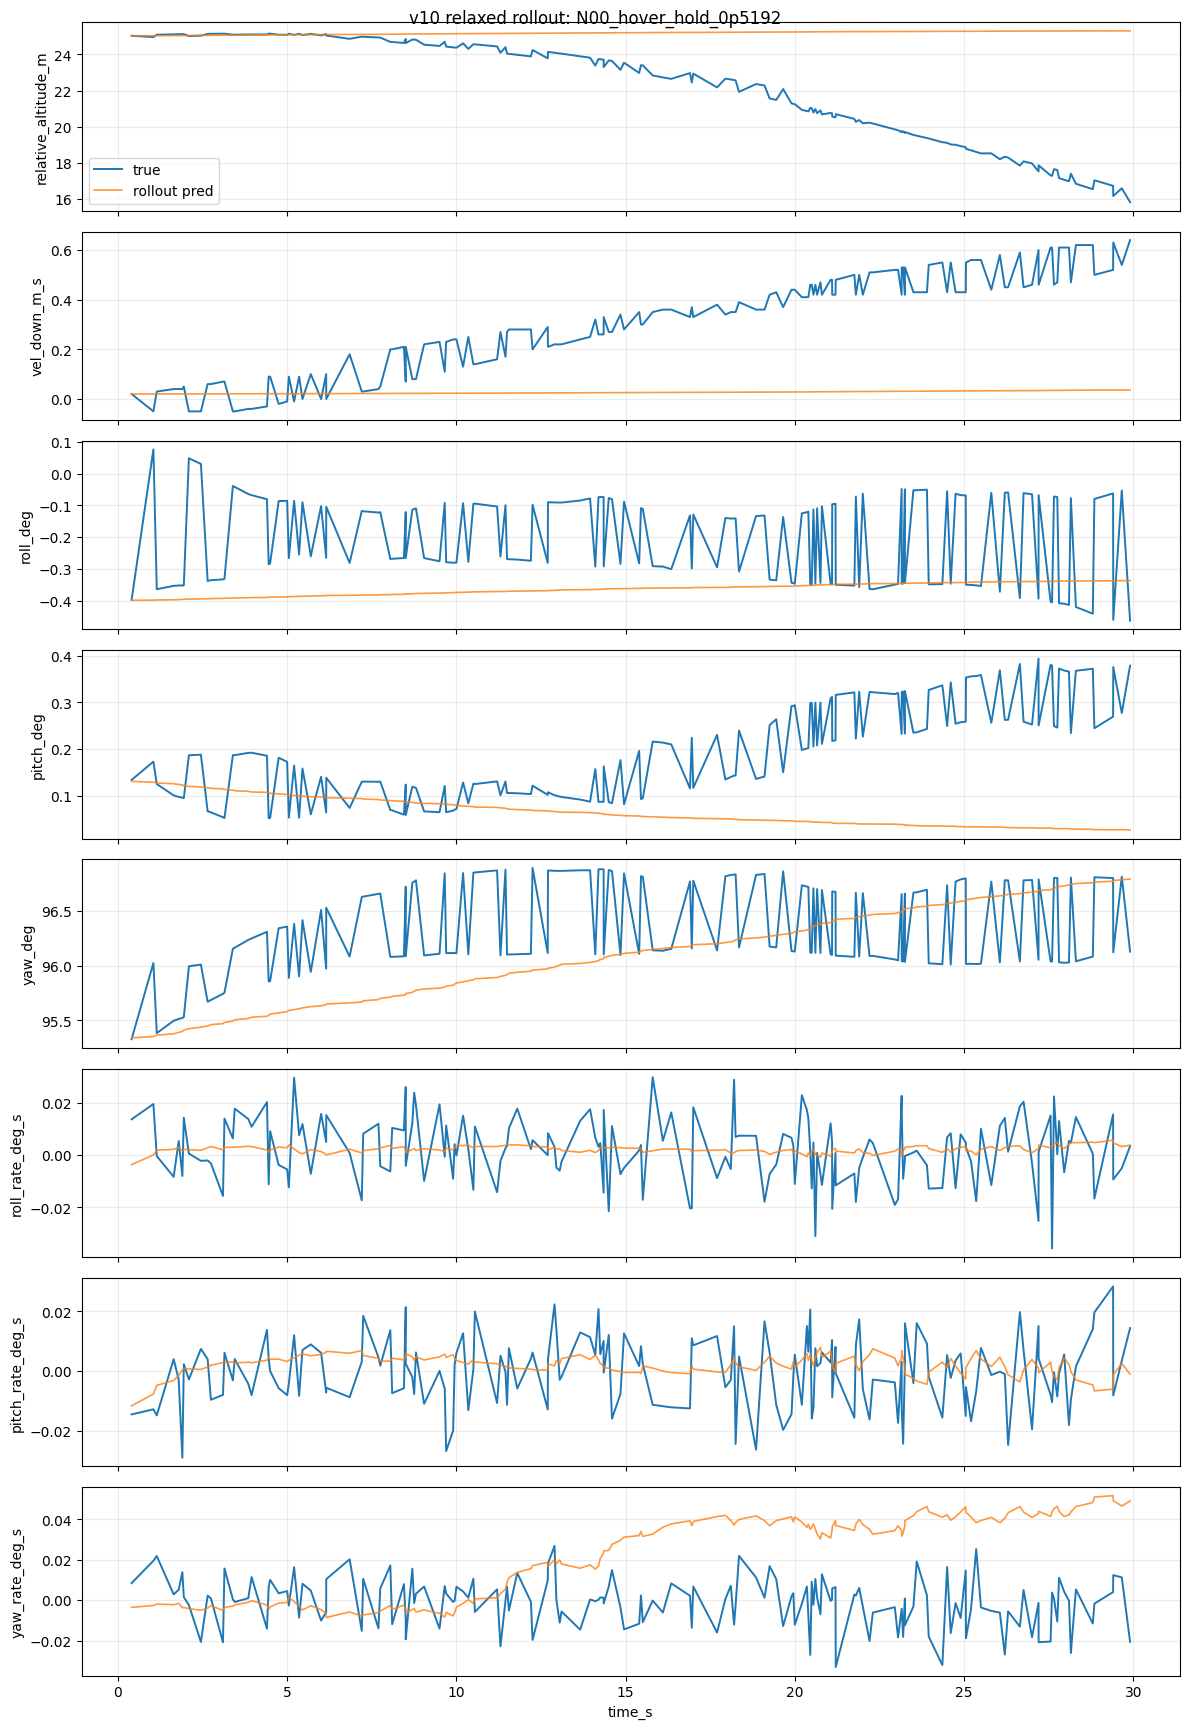

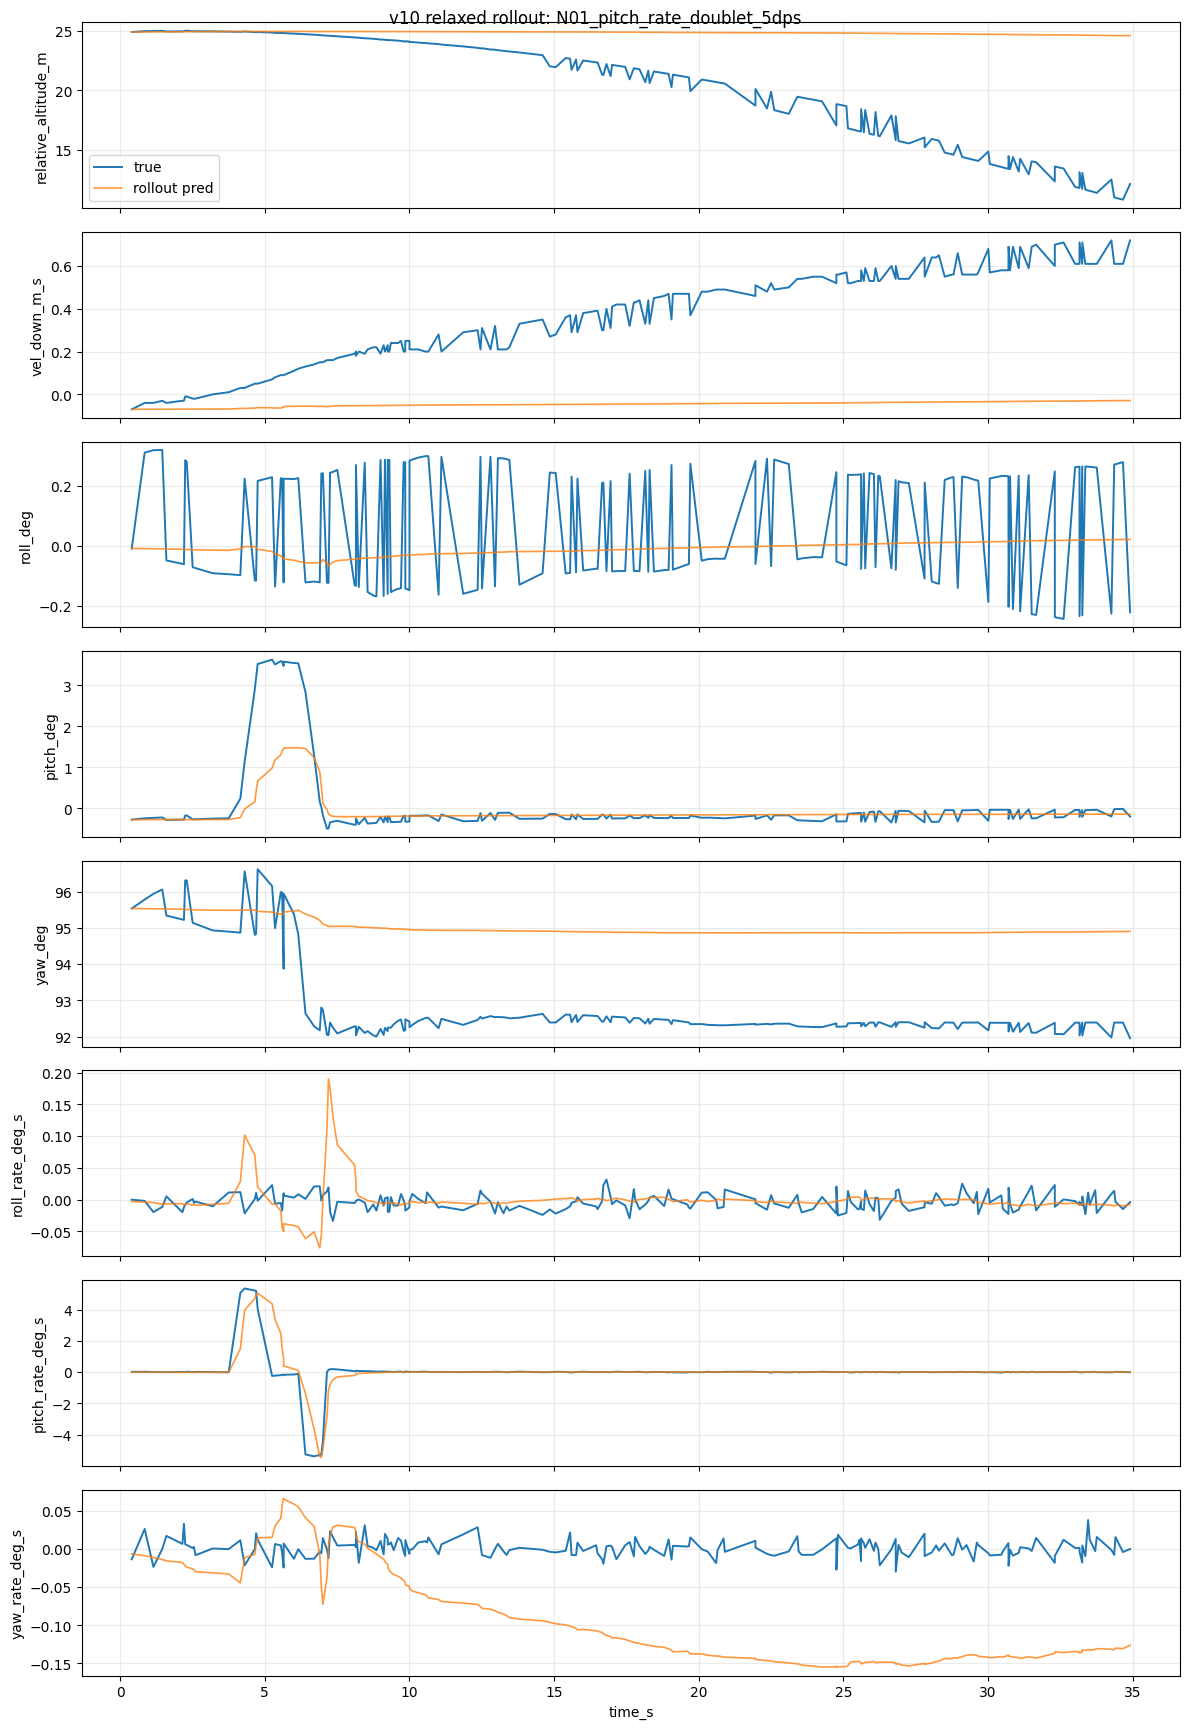

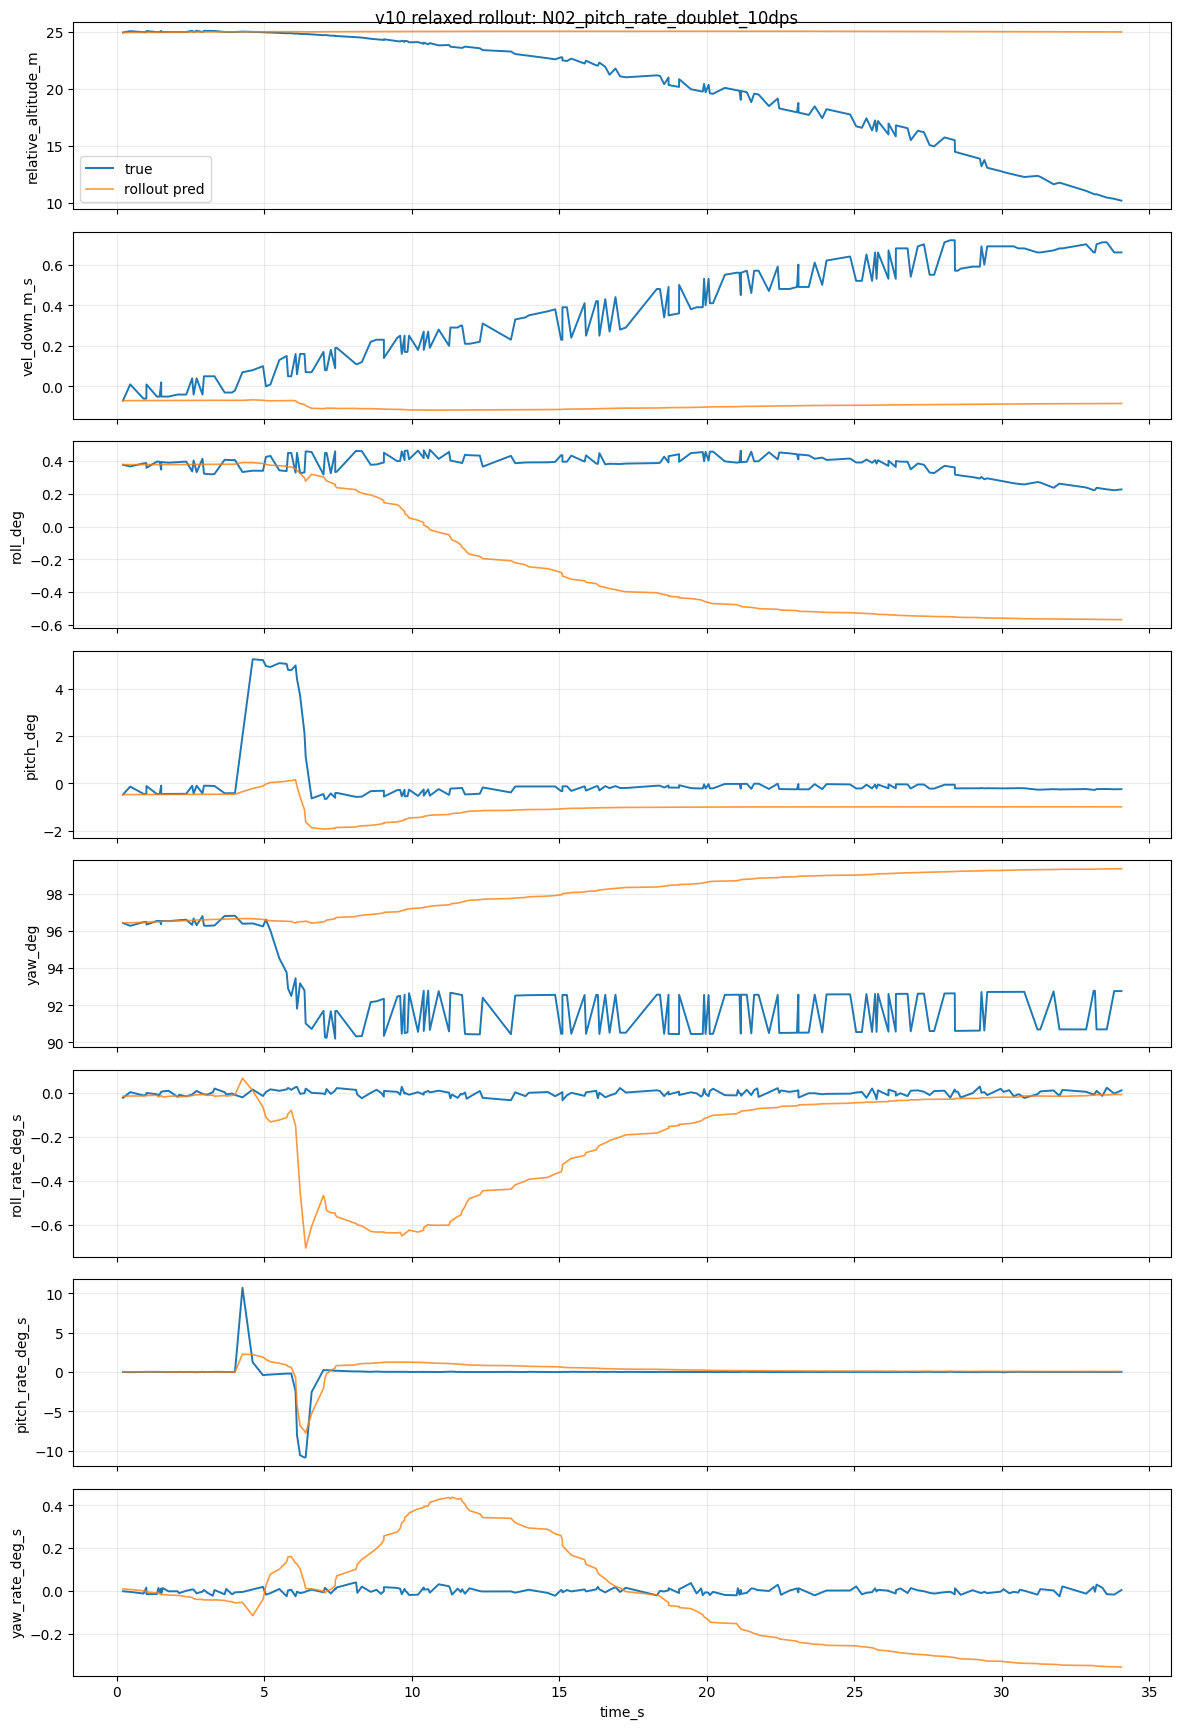

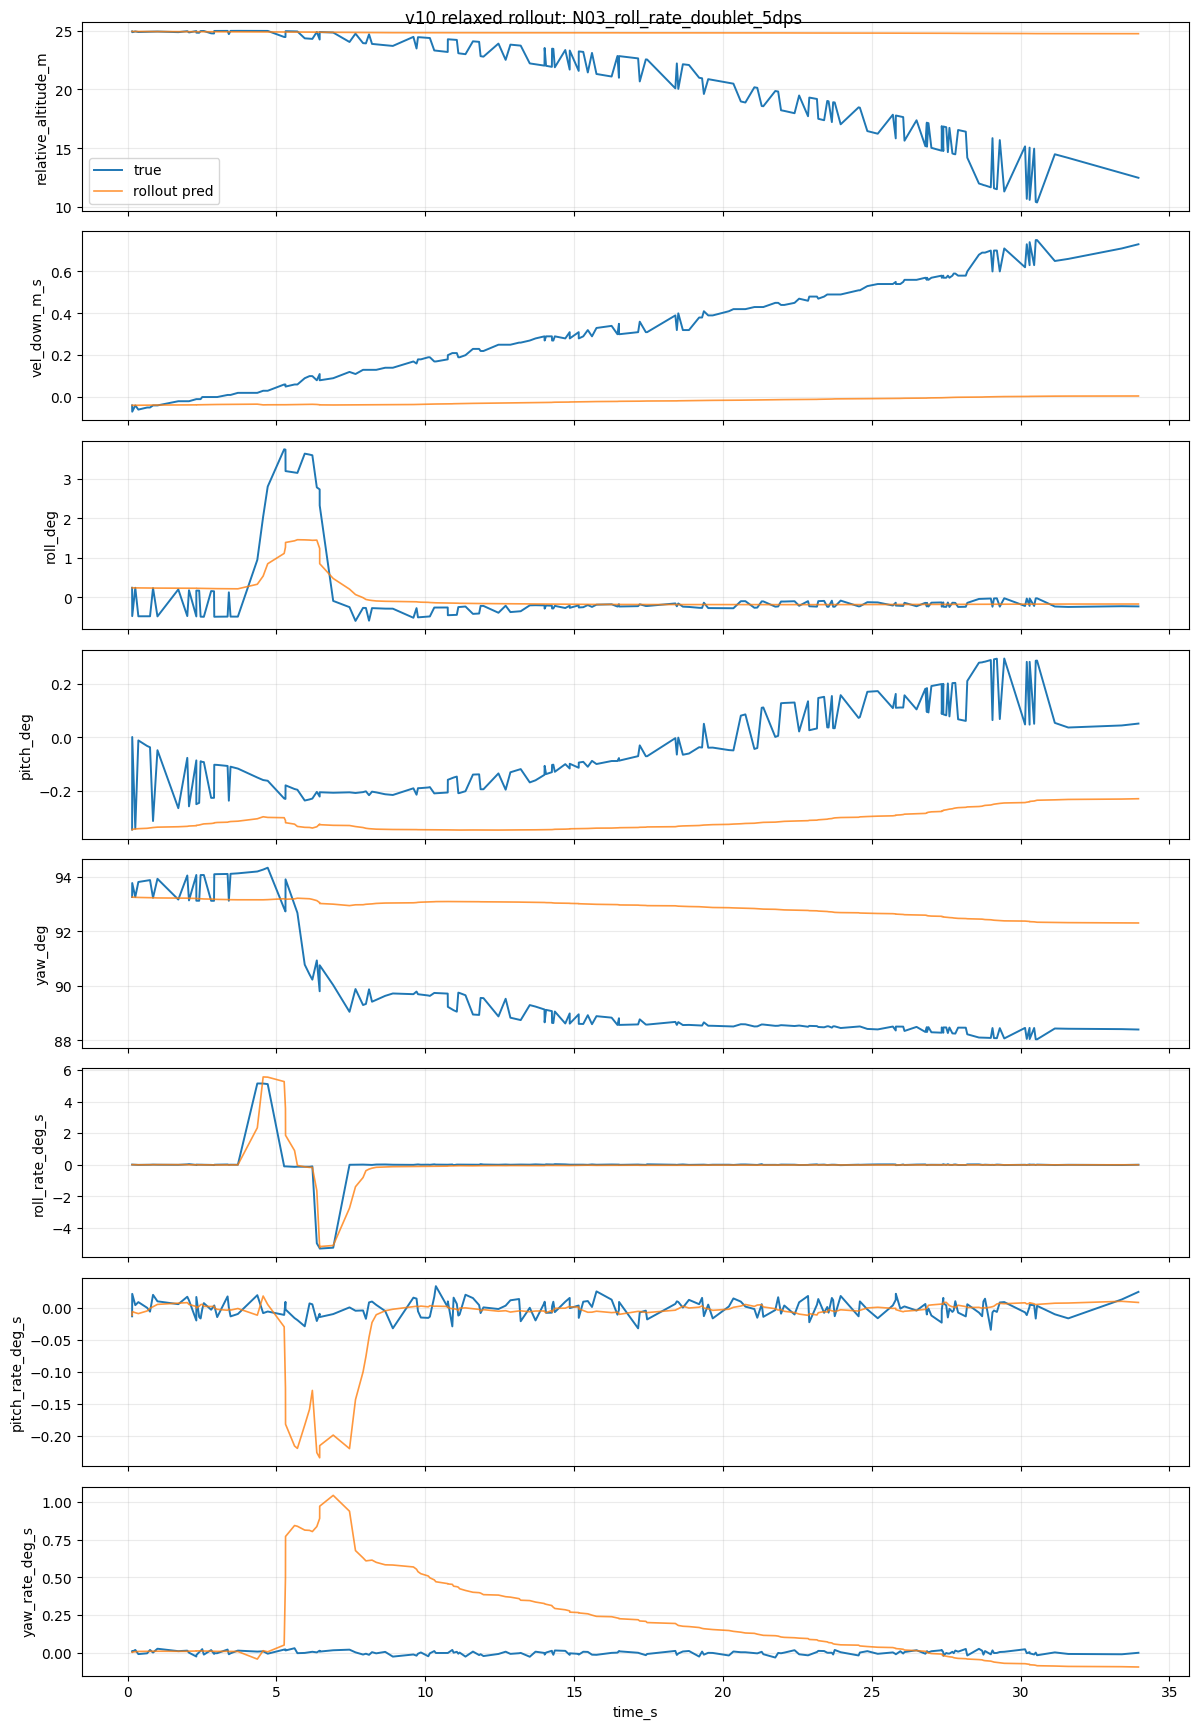

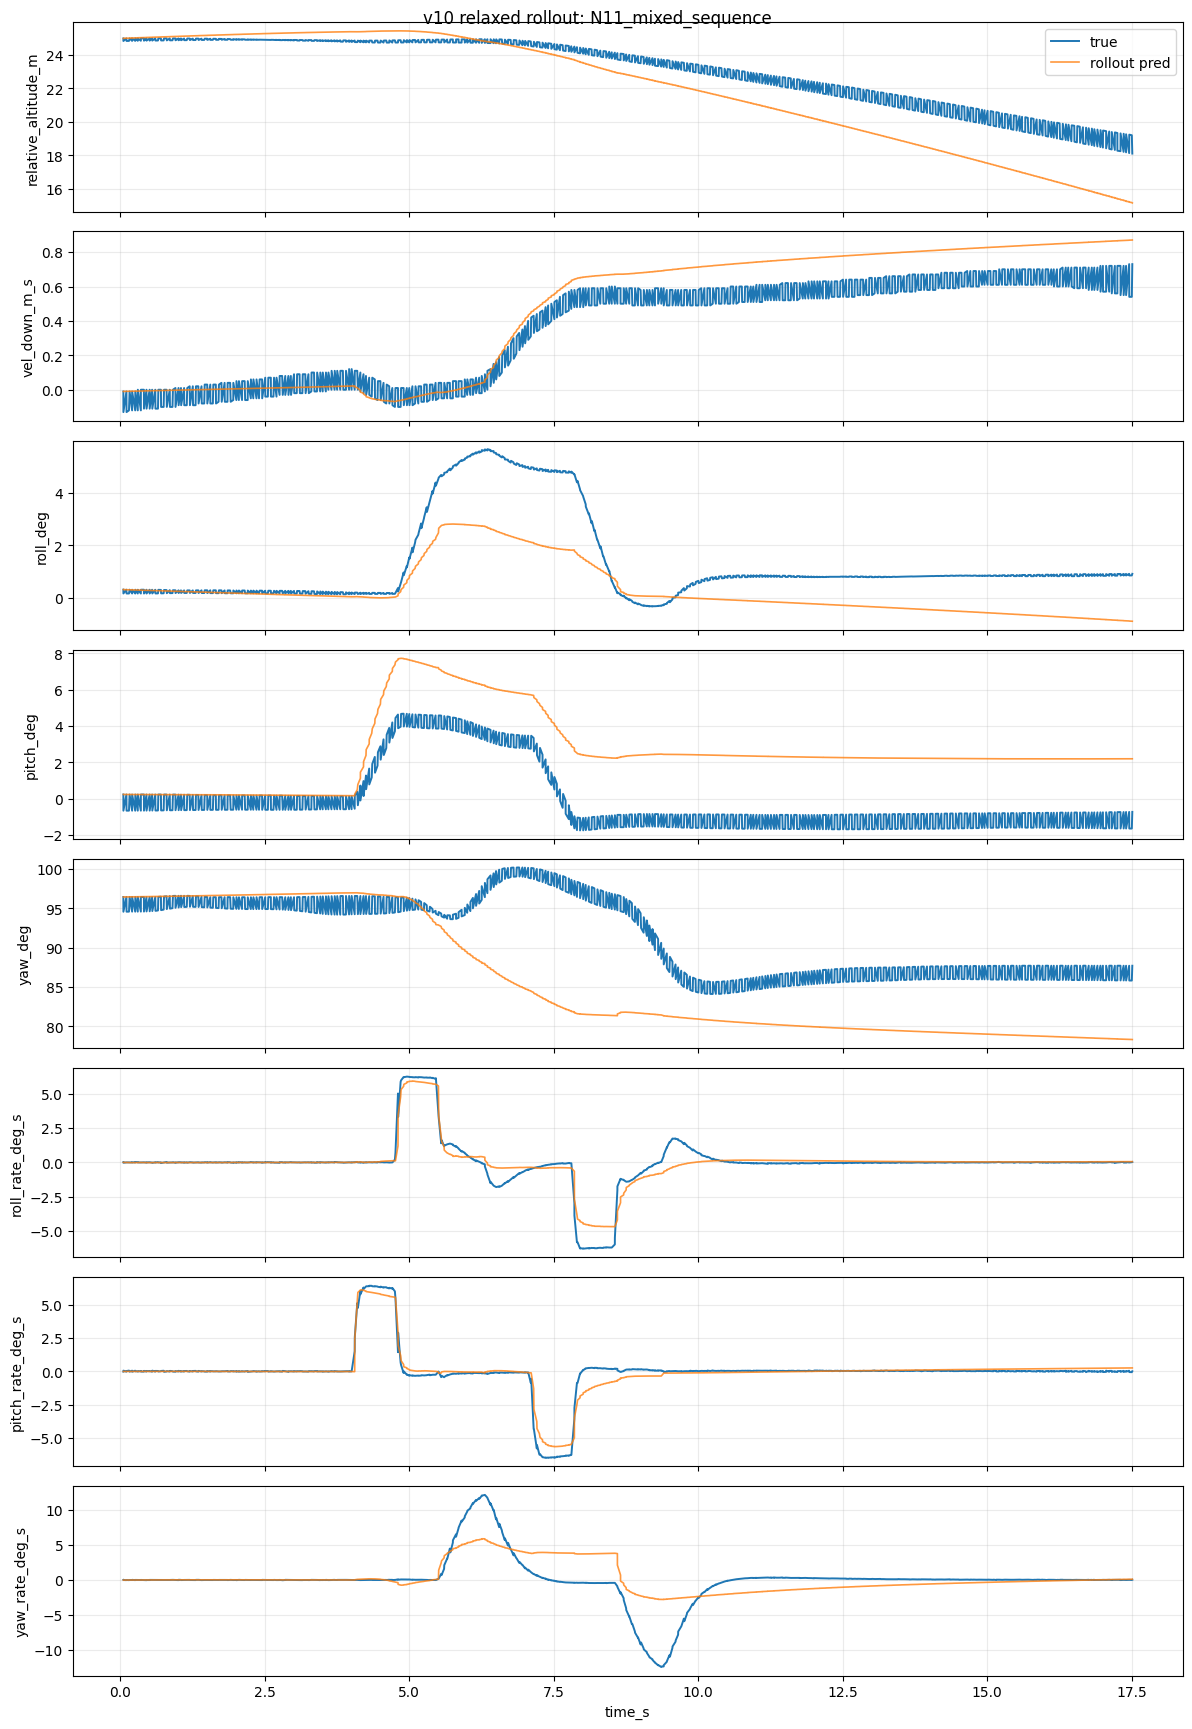

In [10]:
# Plot selected rollouts

def plot_rollout(df,scenario,max_steps=700):
    res=rollout_scenario(df,scenario,max_steps=max_steps)
    if res is None:
        print('not enough rows',scenario); return
    _,sdf,pred,true_next=res; t=sdf['time_s'].to_numpy()
    plot_states=[s for s in ['relative_altitude_m','vel_down_m_s','roll_deg','pitch_deg','yaw_deg','roll_rate_rad_s','pitch_rate_rad_s','yaw_rate_rad_s'] if s in state_cols]
    fig,axes=plt.subplots(len(plot_states),1,figsize=(12,2.2*len(plot_states)),sharex=True)
    if len(plot_states)==1: axes=[axes]
    for ax,state in zip(axes,plot_states):
        j=state_cols.index(state); yt=true_next[:,j]; yp=pred[:,j]
        label=state
        if state.endswith('_rad_s'):
            yt=np.rad2deg(yt); yp=np.rad2deg(yp); label=state.replace('_rad_s','_deg_s')
        ax.plot(t,yt,label='true',lw=1.4); ax.plot(t,yp,label='rollout pred',lw=1.2,alpha=.8); ax.set_ylabel(label); ax.grid(True,alpha=.25)
    axes[0].legend(); axes[-1].set_xlabel('time_s'); fig.suptitle(f'v10 relaxed rollout: {scenario}'); plt.tight_layout(); plt.show()

for scenario in sorted(test_df['scenario'].unique())[:4]: plot_rollout(test_df,scenario)
if len(stress_test_df) and 'N11_mixed_sequence' in set(stress_test_df['scenario']): plot_rollout(stress_test_df,'N11_mixed_sequence')


In [11]:
# Save checkpoint
SAVE_ROOT=Path('/content/drive/MyDrive/PX4_Phase1_Models') if IN_COLAB else DATASET_PATH/'models'
SAVE_ROOT.mkdir(parents=True,exist_ok=True)
stamp=time.strftime('%Y%m%d_%H%M%S')
ckpt_path=SAVE_ROOT/f'px4_phase1_rate_dynamics_mlp_v10_relaxed_nominal_test_{stamp}.pt'
checkpoint={
    'model_version':'px4_phase1_rate_dynamics_mlp_v10_relaxed_nominal_test',
    'state_dict':model.state_dict(),
    'model_config':{'n_in':len(feature_cols),'n_out':len(target_cols),'n_aux':len(aux_cols),**MODEL_CONFIG},
    'feature_cols':feature_cols,'target_cols':target_cols,'aux_cols':aux_cols,'state_cols':state_cols,'action_cols':action_cols,
    'x_scaler':x_scaler.to_dict(feature_cols),'y_scaler':y_scaler.to_dict(target_cols),'aux_scaler':a_scaler.to_dict(aux_cols),
    'loss_config':{'data_weight':DATA_WEIGHT,'aux_weight':AUX_WEIGHT,'alt_kin_weight':ALT_KIN_WEIGHT,'euler_kin_weight':EULER_KIN_WEIGHT,'aux_consistency_weight':AUX_CONSISTENCY_WEIGHT,'stress_scenarios':STRESS_SCENARIOS},
    'dataset_path':str(DATASET_PATH),'metadata':metadata,'history':hist_df.to_dict(orient='records'),'one_step_metrics':metrics_df.to_dict(orient='records'),'aux_metrics':aux_metrics_df.to_dict(orient='records'),'rollout_metrics':rollout_metrics_df.to_dict(orient='records')
}
torch.save(checkpoint,ckpt_path)
print('saved:',ckpt_path)


saved: /content/drive/MyDrive/PX4_Phase1_Models/px4_phase1_rate_dynamics_mlp_v10_relaxed_nominal_test_20260508_091519.pt


In [12]:
# Minimal load check
loaded=torch.load(ckpt_path,map_location='cpu')
print('loaded keys:',sorted(loaded.keys()))
print('feature/target/aux:',len(loaded['feature_cols']),len(loaded['target_cols']),len(loaded['aux_cols']))


loaded keys: ['action_cols', 'aux_cols', 'aux_metrics', 'aux_scaler', 'dataset_path', 'feature_cols', 'history', 'loss_config', 'metadata', 'model_config', 'model_version', 'one_step_metrics', 'rollout_metrics', 'state_cols', 'state_dict', 'target_cols', 'x_scaler', 'y_scaler']
feature/target/aux: 23 10 6
